### **GROUP 2: Water Quality and Potability Modeling**

In [88]:
import pandas as pd # Imports the Pandas library for data manipulation and analysis
import matplotlib.pyplot as plt # Imports Matplotlib's plotting interface for creating visualizations
import numpy as np # Imports NumPy for numerical computing
import seaborn as sns # Better-looking visualizations for EDA

# Preprocessing

# LabelEncoder Converts categorical text labels into numbers (e.g., "Yes"/"No" → 1/0) - Not needed since features are already numeric
# MinMaxScaler scales features to a fixed range (usually 0 to 1) - (if you use KNN or Neural Networks)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Splits data into training and testing sets (80% for training models, 20% for testing)
from sklearn.model_selection import train_test_split

# Handle missing values (pH, Sulfate, etc.)
from sklearn.impute import SimpleImputer

# Models

from sklearn.neighbors import KNeighborsClassifier # Imports the K-Nearest Neighbors classification algorithm
from sklearn.linear_model import LogisticRegression # Imports the Logistic Regression algorithm
from sklearn.svm import SVC # Imports Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier # Imports Random Forest classifier (ensemble of decision trees). Builds multiple decision trees and averages their predictions
from sklearn.tree import DecisionTreeClassifier # Imports single Decision Tree classifier. Creates a tree of if/else decisions based on features. Prone to overfitting (Simpler version of Random Forest)

# Evaluate models on the test set

# classification_report	- prints precision, recall, f1-score for each class.
# confusion_matrix	Shows true/false positives/negatives (how many correct/incorrect)
# accuracy_score	Calculates (correct predictions / total predictions)
# roc_auc_score	Measures model's ability to distinguish between classes (0.5 = random, 1.0 = perfect)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score

# Imports joblib for saving/loading Python objects (models, scalers). Saves trained model to a file so you can load it later without retraining
import joblib

import warnings # Imports Python's warning system
warnings.filterwarnings('ignore') # Suppresses all warning messages



#### Steps for EDA on the dataset

1. Loading the Data
2. Initial Data Inspection
3. Summary Statistics
4. Missing Values Analysis
5. Data Cleaning
6. Data Visualization

### 1. Loading the Data

In [89]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load Data
water_potability = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/water_potability.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
# Display the first 10 rows
water_potability.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


#### 2. Initial Data Inspection
Inspect the basic structure and summary of the dataset.

In [91]:
# Display basic information about the dataset
water_potability.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


#### 3. Summary Statistics
Generate summary statistics for numerical and categorical features.

In [92]:
# Summary statistics for numerical features
numerical_summary = water_potability.describe()
print("Numerical Summary:\n")
numerical_summary

Numerical Summary:



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### 4. Missing Values Analysis
Identify missing values in the dataset.

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


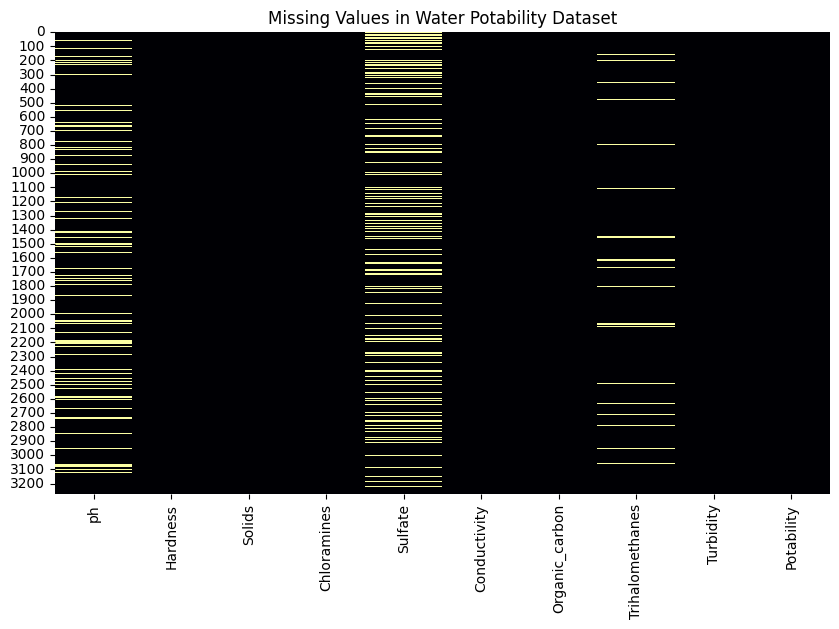

In [93]:
missing_values = water_potability.isna().sum() # This checks for null values in the various columns
print(missing_values)

# Visualizing missing values
plt.figure(figsize=(10, 6))
sns.heatmap(water_potability.isnull(), cbar=False, cmap='inferno')
plt.title('Missing Values in Water Potability Dataset')
plt.show()

In [94]:
print(water_potability['Potability'].value_counts())


Potability
0    1998
1    1278
Name: count, dtype: int64


#### 5. Data Visualization
Create various plots to visualize the data.

##### **Count Plot**

This shows how many water samples are potable vs not portable

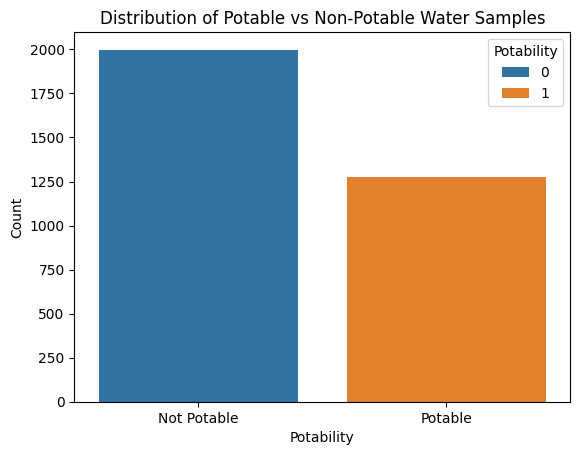

In [95]:
# Count plot for Potability
sns.countplot(x='Potability', data=water_potability,hue='Potability')
plt.title('Distribution of Potable vs Non-Potable Water Samples')
plt.xticks([0, 1], ['Not Potable', 'Potable'])
plt.ylabel('Count')
plt.show()


#### **Histogram of All Features**

Shows the spread and shape of the 3 most important water quality measurements

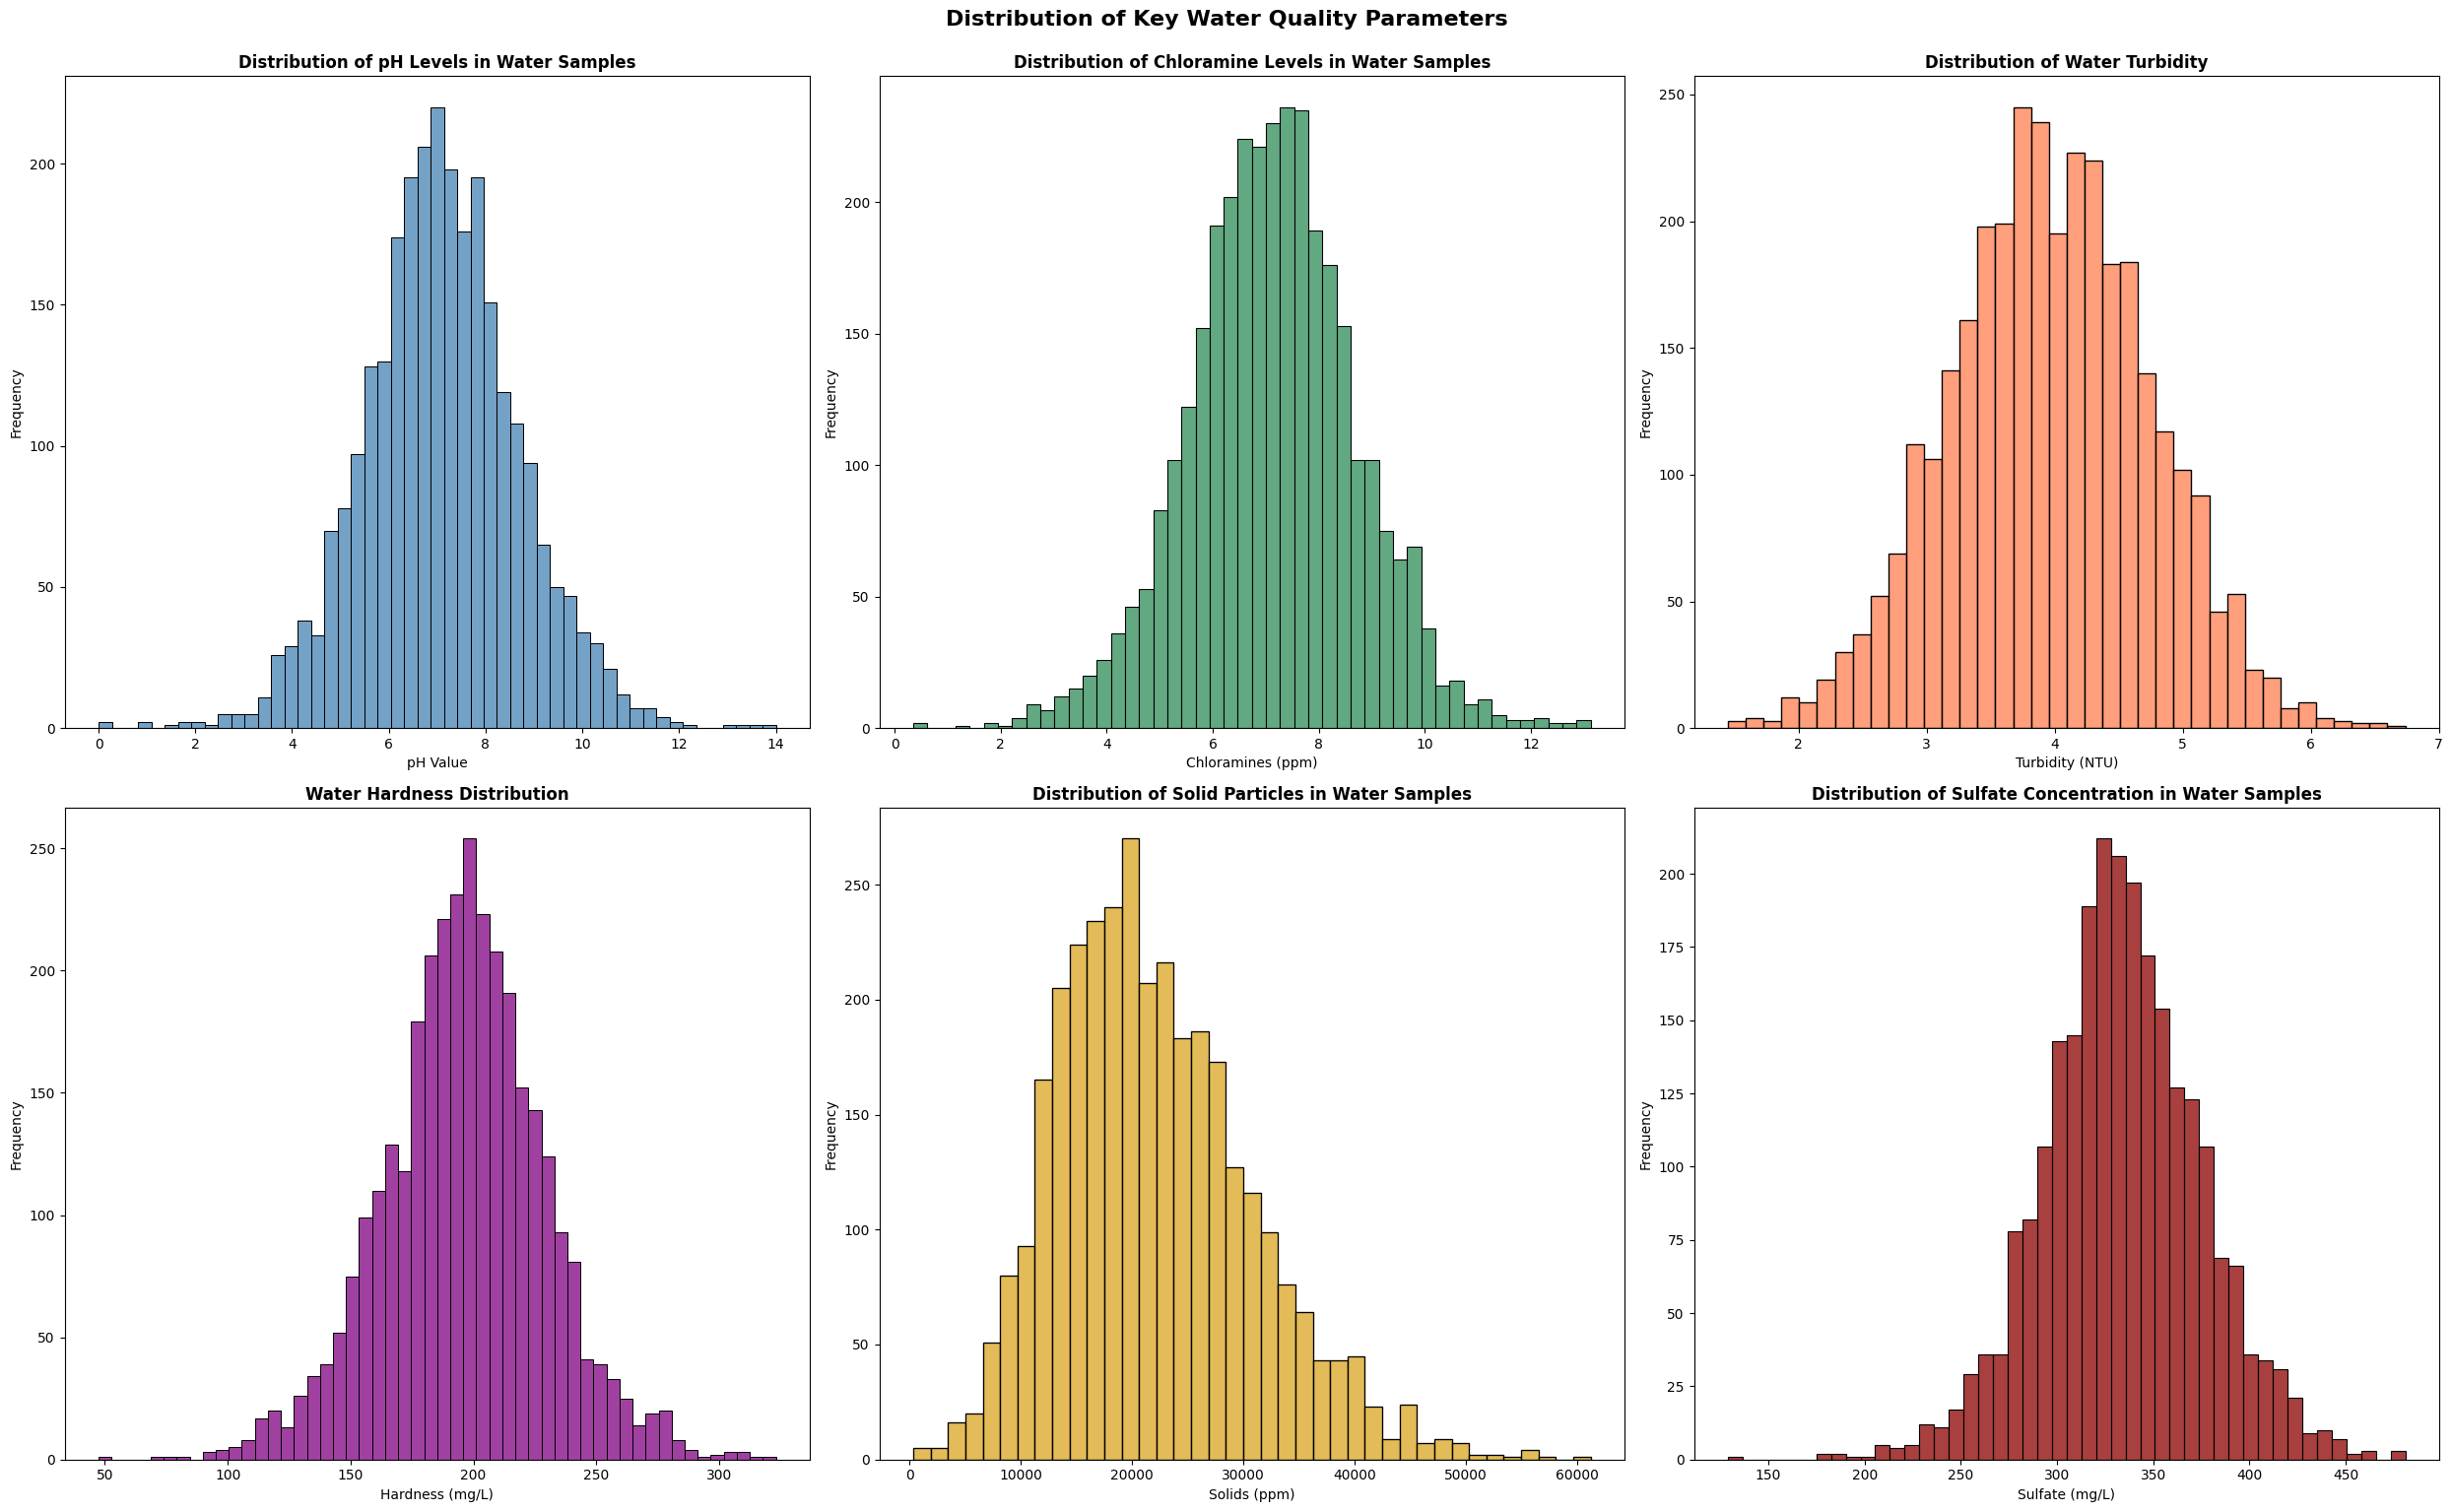

In [96]:
# Set up the matplotlib figure for histograms
plt.figure(figsize=(25, 15))


# Subplot 1: pH
plt.subplot(2, 3, 1)
sns.histplot(water_potability['ph'].dropna(), kde=False, color='steelblue')
plt.title('Distribution of pH Levels in Water Samples', fontweight='bold')
plt.xlabel('pH Value')
plt.ylabel('Frequency')

# Subplot 2: Chloramines
plt.subplot(2, 3, 2)
sns.histplot(water_potability['Chloramines'].dropna(), kde=False, color='seagreen')
plt.title('Distribution of Chloramine Levels in Water Samples', fontweight='bold')
plt.xlabel('Chloramines (ppm)')
plt.ylabel('Frequency')

# Subplot 3: Turbidity
plt.subplot(2, 3, 3)
sns.histplot(water_potability['Turbidity'].dropna(), kde=False, color='coral')
plt.title('Distribution of Water Turbidity', fontweight='bold')
plt.xlabel('Turbidity (NTU)')
plt.ylabel('Frequency')

# Subplot 4: Hardness
plt.subplot(2, 3, 4)
sns.histplot(water_potability['Hardness'].dropna(), kde=False, color='purple')
plt.title('Water Hardness Distribution', fontweight='bold')
plt.xlabel('Hardness (mg/L)')
plt.ylabel('Frequency')

# Subplot 5: Solids
plt.subplot(2, 3, 5)
sns.histplot(water_potability['Solids'].dropna(), kde=False, color='goldenrod')
plt.title('Distribution of Solid Particles in Water Samples', fontweight='bold')
plt.xlabel('Solids (ppm)')
plt.ylabel('Frequency')

# Subplot 6: Sulfate (FIXED: typo in title)
plt.subplot(2, 3, 6)
sns.histplot(water_potability['Sulfate'].dropna(), kde=False, color='darkred')
plt.title('Distribution of Sulfate Concentration in Water Samples', fontweight='bold')
plt.xlabel('Sulfate (mg/L)')
plt.ylabel('Frequency')

# Adjust spacing and display
plt.tight_layout()
plt.suptitle('Distribution of Key Water Quality Parameters', fontsize=16, fontweight='bold', y=1.02)
plt.show()


##### Correlation Heatmap

Shows how strongly each feature relates to each other and potability

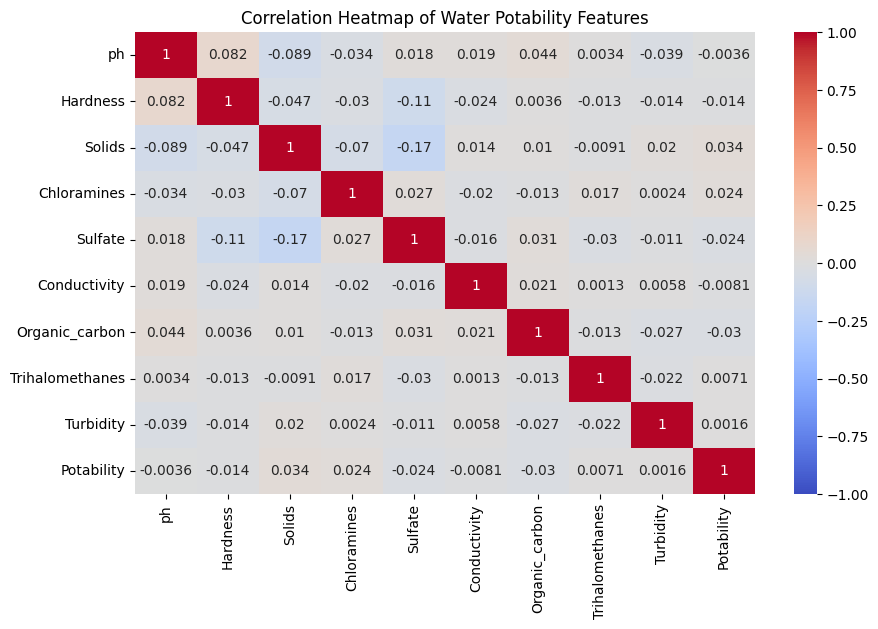

In [97]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
numerical_cols = water_potability.select_dtypes(include=['float64','int64'])
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Water Potability Features")
plt.show()


#### Boxplots by Potability Class

Compares each feature between potable and non-potable water

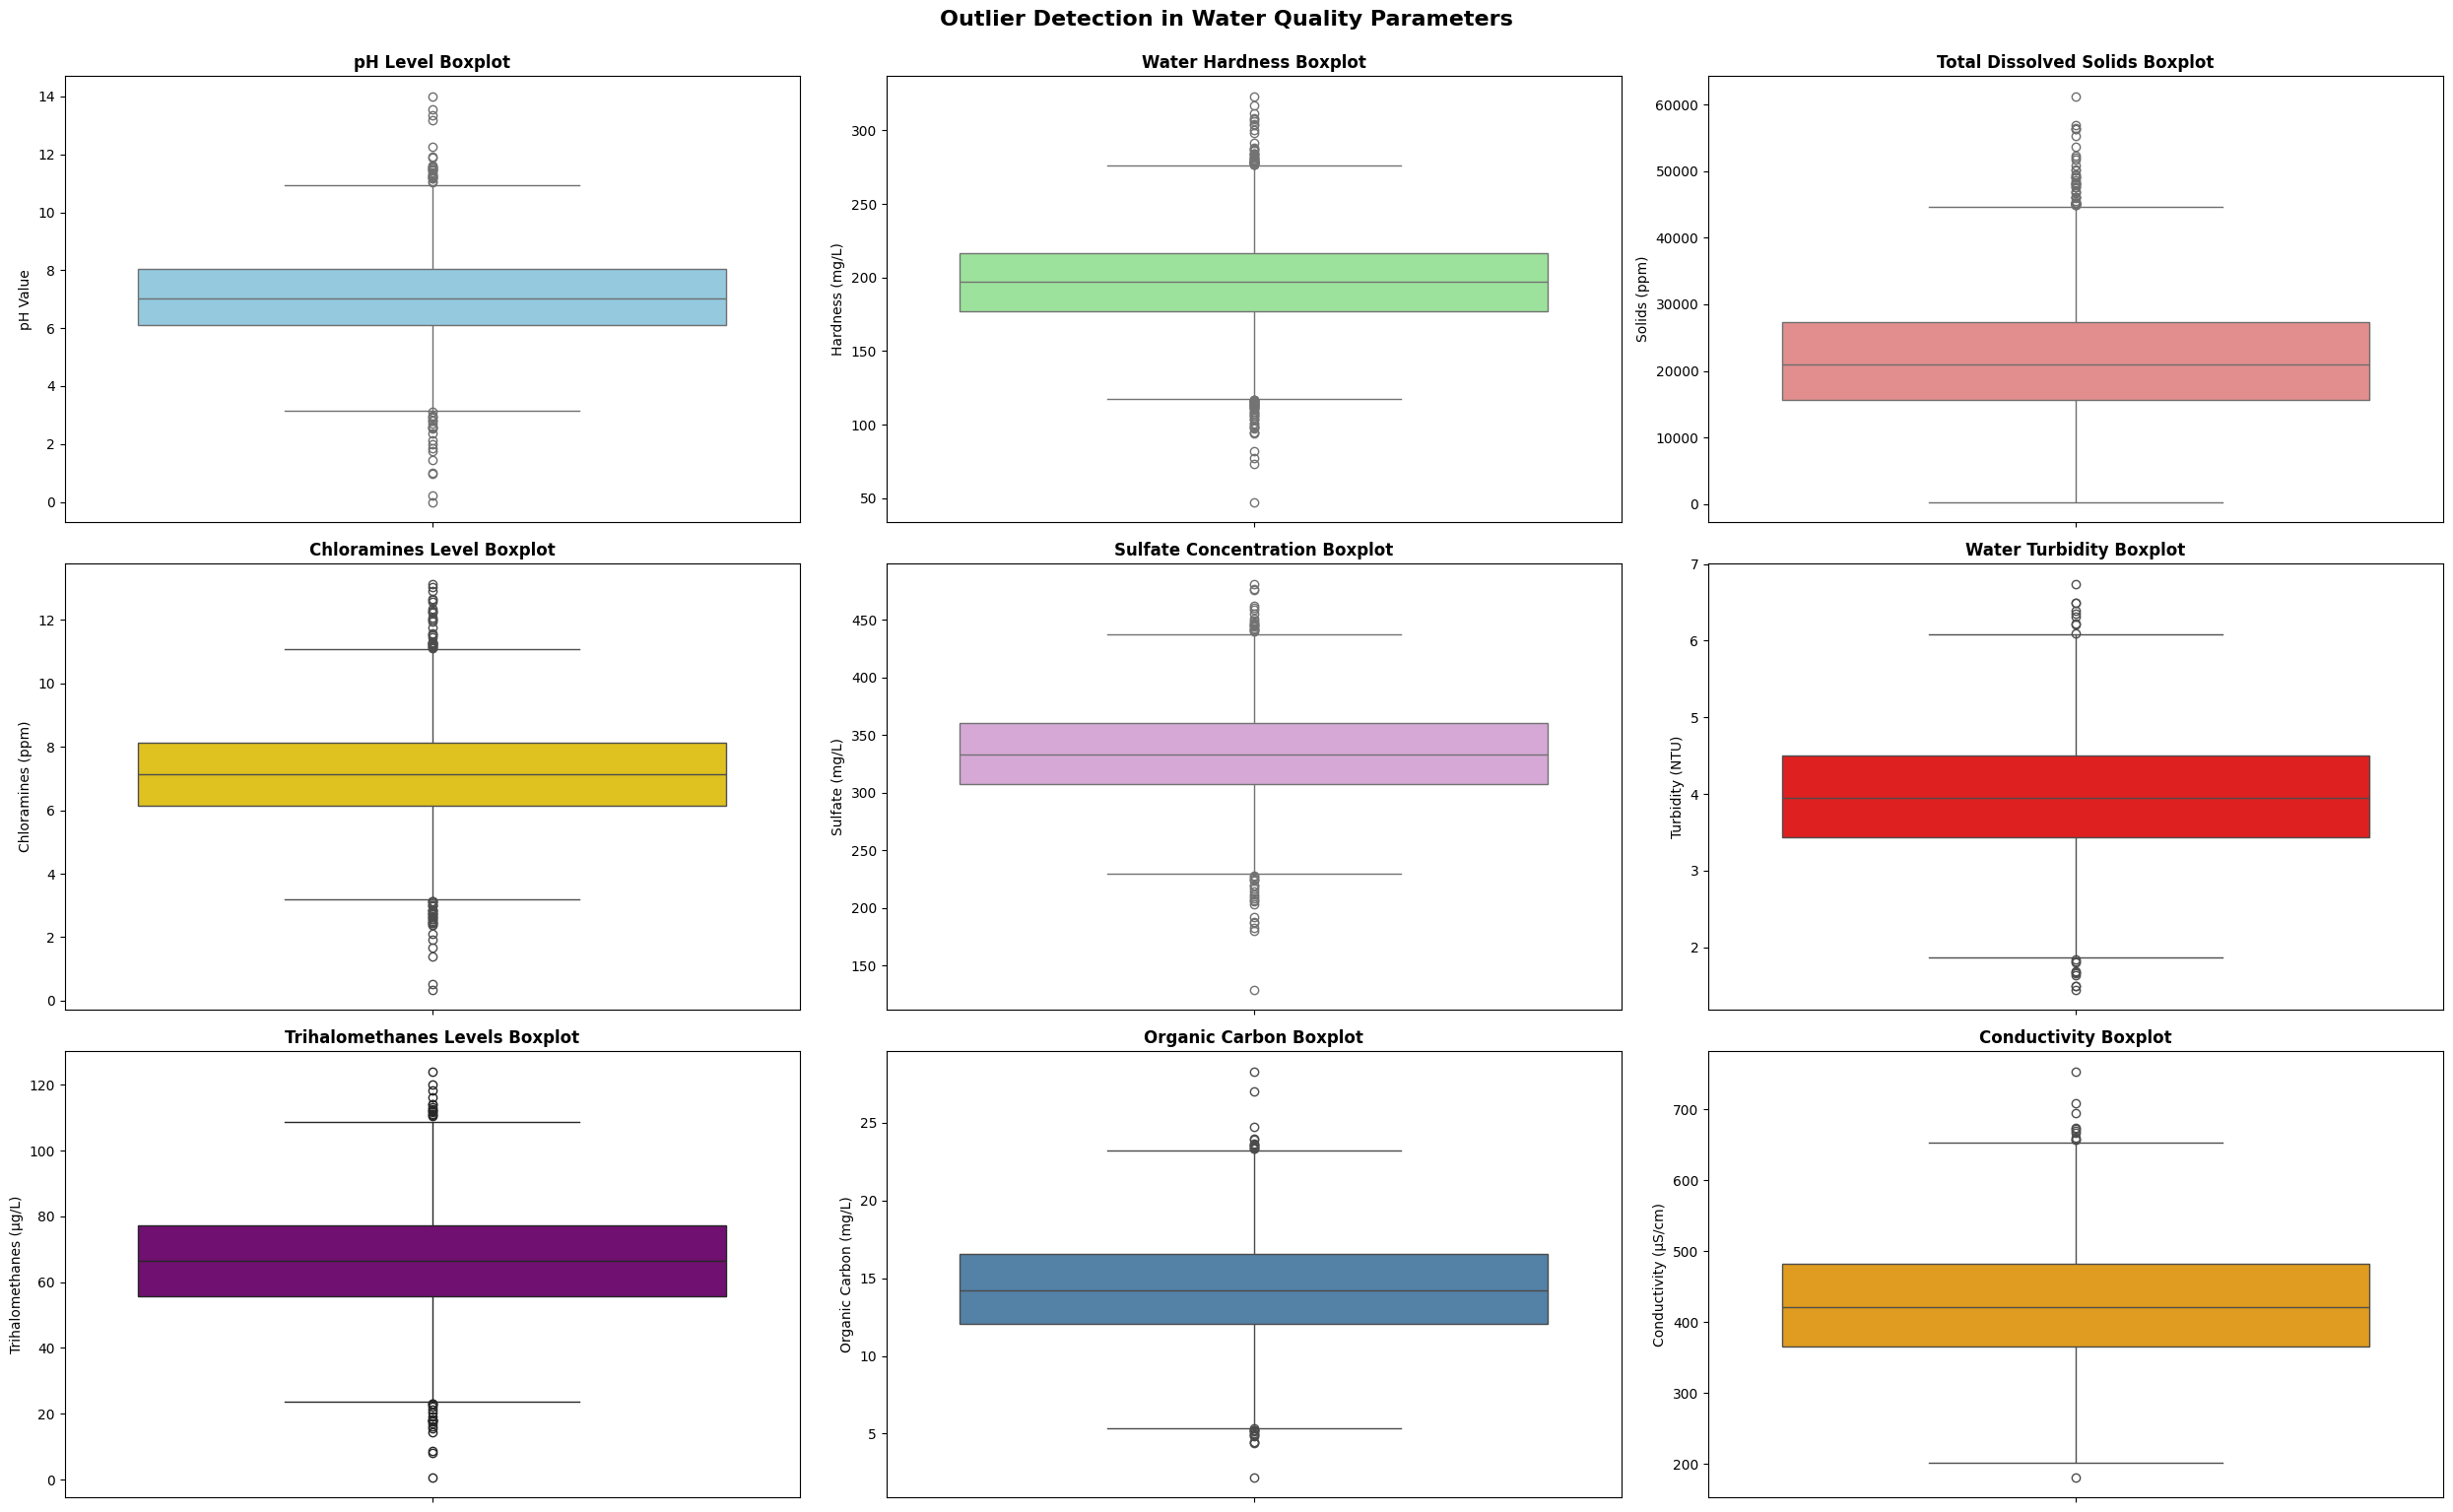

In [98]:
# Set up the matplotlib figure for boxplots of all numerical columns
plt.figure(figsize=(25, 15))


plt.subplot(3, 3, 1)
box1 = sns.boxplot(y=water_potability['ph'].dropna(), color='skyblue')
plt.title('pH Level Boxplot', fontweight='bold')
plt.ylabel('pH Value')

plt.subplot(3, 3, 2)
box2 = sns.boxplot(y=water_potability['Hardness'].dropna(), color='lightgreen')
plt.title('Water Hardness Boxplot', fontweight='bold')
plt.ylabel('Hardness (mg/L)')

plt.subplot(3, 3, 3)
box3 = sns.boxplot(y=water_potability['Solids'].dropna(), color='lightcoral')
plt.title('Total Dissolved Solids Boxplot', fontweight='bold')
plt.ylabel('Solids (ppm)')

plt.subplot(3, 3, 4)
box4 = sns.boxplot(y=water_potability['Chloramines'].dropna(), color='gold')
plt.title('Chloramines Level Boxplot', fontweight='bold')
plt.ylabel('Chloramines (ppm)')

plt.subplot(3, 3, 5)
box5 = sns.boxplot(y=water_potability['Sulfate'].dropna(), color='plum')
plt.title('Sulfate Concentration Boxplot', fontweight='bold')
plt.ylabel('Sulfate (mg/L)')

plt.subplot(3, 3, 6)
sns.boxplot(y=water_potability['Turbidity'].dropna(), color='red')
plt.title('Water Turbidity Boxplot', fontweight='bold')
plt.ylabel('Turbidity (NTU)')

plt.subplot(3, 3, 7)
box7 = sns.boxplot(y=water_potability['Trihalomethanes'].dropna(), color='purple')
plt.title('Trihalomethanes Levels Boxplot', fontweight='bold')
plt.ylabel('Trihalomethanes (µg/L)')

plt.subplot(3, 3, 8)
box8 = sns.boxplot(y=water_potability['Organic_carbon'].dropna(), color='steelblue')
plt.title('Organic Carbon Boxplot', fontweight='bold')
plt.ylabel('Organic Carbon (mg/L)')

plt.subplot(3, 3, 9)
box9 = sns.boxplot(y=water_potability['Conductivity'].dropna(), color='orange')
plt.title('Conductivity Boxplot', fontweight='bold')
plt.ylabel('Conductivity (µS/cm)')

plt.tight_layout()
plt.suptitle('Outlier Detection in Water Quality Parameters', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [99]:
# Removing outliers:  CAPPING (Recommended - No data loss)

def cap_outliers(df, columns):

    df_capped = df.copy()  # Work on a copy

    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers before capping
        outliers_before = ((df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)).sum()
        print(f"{col}: Capping {outliers_before} outliers ({outliers_before/len(df_capped)*100:.1f}%)")

        # Cap the values (NOT remove rows)
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

    return df_capped

# Columns to check for outliers
columns_to_check = ['ph', 'Hardness', 'Solids', 'Sulfate', 'Chloramines',
                    'Turbidity', 'Trihalomethanes', 'Conductivity', 'Organic_carbon']

# Cap outliers
water_potability_clean = cap_outliers(water_potability, columns_to_check)

print(f"Original data shape: {water_potability.shape}")
print(f"Cleaned data shape: {water_potability_clean.shape}")
print(f"Rows lost: {water_potability.shape[0] - water_potability_clean.shape[0]}")  # Should be 0

# For the water quality project, capping is actually better because:
# The dataset only has 3,276 rows — removing outliers shrunk it further to 179, 010 (nearly half of the data)
# Capping keeps all the data while still controlling extreme values
# More data generally means better model performance

ph: Capping 46 outliers (1.4%)
Hardness: Capping 83 outliers (2.5%)
Solids: Capping 47 outliers (1.4%)
Sulfate: Capping 41 outliers (1.3%)
Chloramines: Capping 61 outliers (1.9%)
Turbidity: Capping 19 outliers (0.6%)
Trihalomethanes: Capping 33 outliers (1.0%)
Conductivity: Capping 11 outliers (0.3%)
Organic_carbon: Capping 25 outliers (0.8%)
Original data shape: (3276, 10)
Cleaned data shape: (3276, 10)
Rows lost: 0


In [100]:
def cap_outliers_aggressive(df, column, multiplier=1.0):
    """
    More aggressive capping using smaller multiplier.
    multiplier=1.5 is standard
    multiplier=1.0 is stricter (fewer outliers)
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"{column}: Capping {outlier_count} outliers (multiplier={multiplier})")

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply stricter capping to specific columns
water_potability_clean = water_potability.copy()

# Use stricter capping (multiplier=1.0) for these columns
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    water_potability_clean = cap_outliers_aggressive(water_potability_clean, col, multiplier=1.0)

# Use standard capping for others
for col in ['Hardness', 'Solids', 'Chloramines', 'Turbidity', 'Conductivity', 'Organic_carbon']:
    water_potability_clean = cap_outliers_aggressive(water_potability_clean, col, multiplier=1.5)

ph: Capping 191 outliers (multiplier=1.0)
Sulfate: Capping 160 outliers (multiplier=1.0)
Trihalomethanes: Capping 160 outliers (multiplier=1.0)
Hardness: Capping 83 outliers (multiplier=1.5)
Solids: Capping 47 outliers (multiplier=1.5)
Chloramines: Capping 61 outliers (multiplier=1.5)
Turbidity: Capping 19 outliers (multiplier=1.5)
Conductivity: Capping 11 outliers (multiplier=1.5)
Organic_carbon: Capping 25 outliers (multiplier=1.5)


### Post-Outlier Removal Visualization

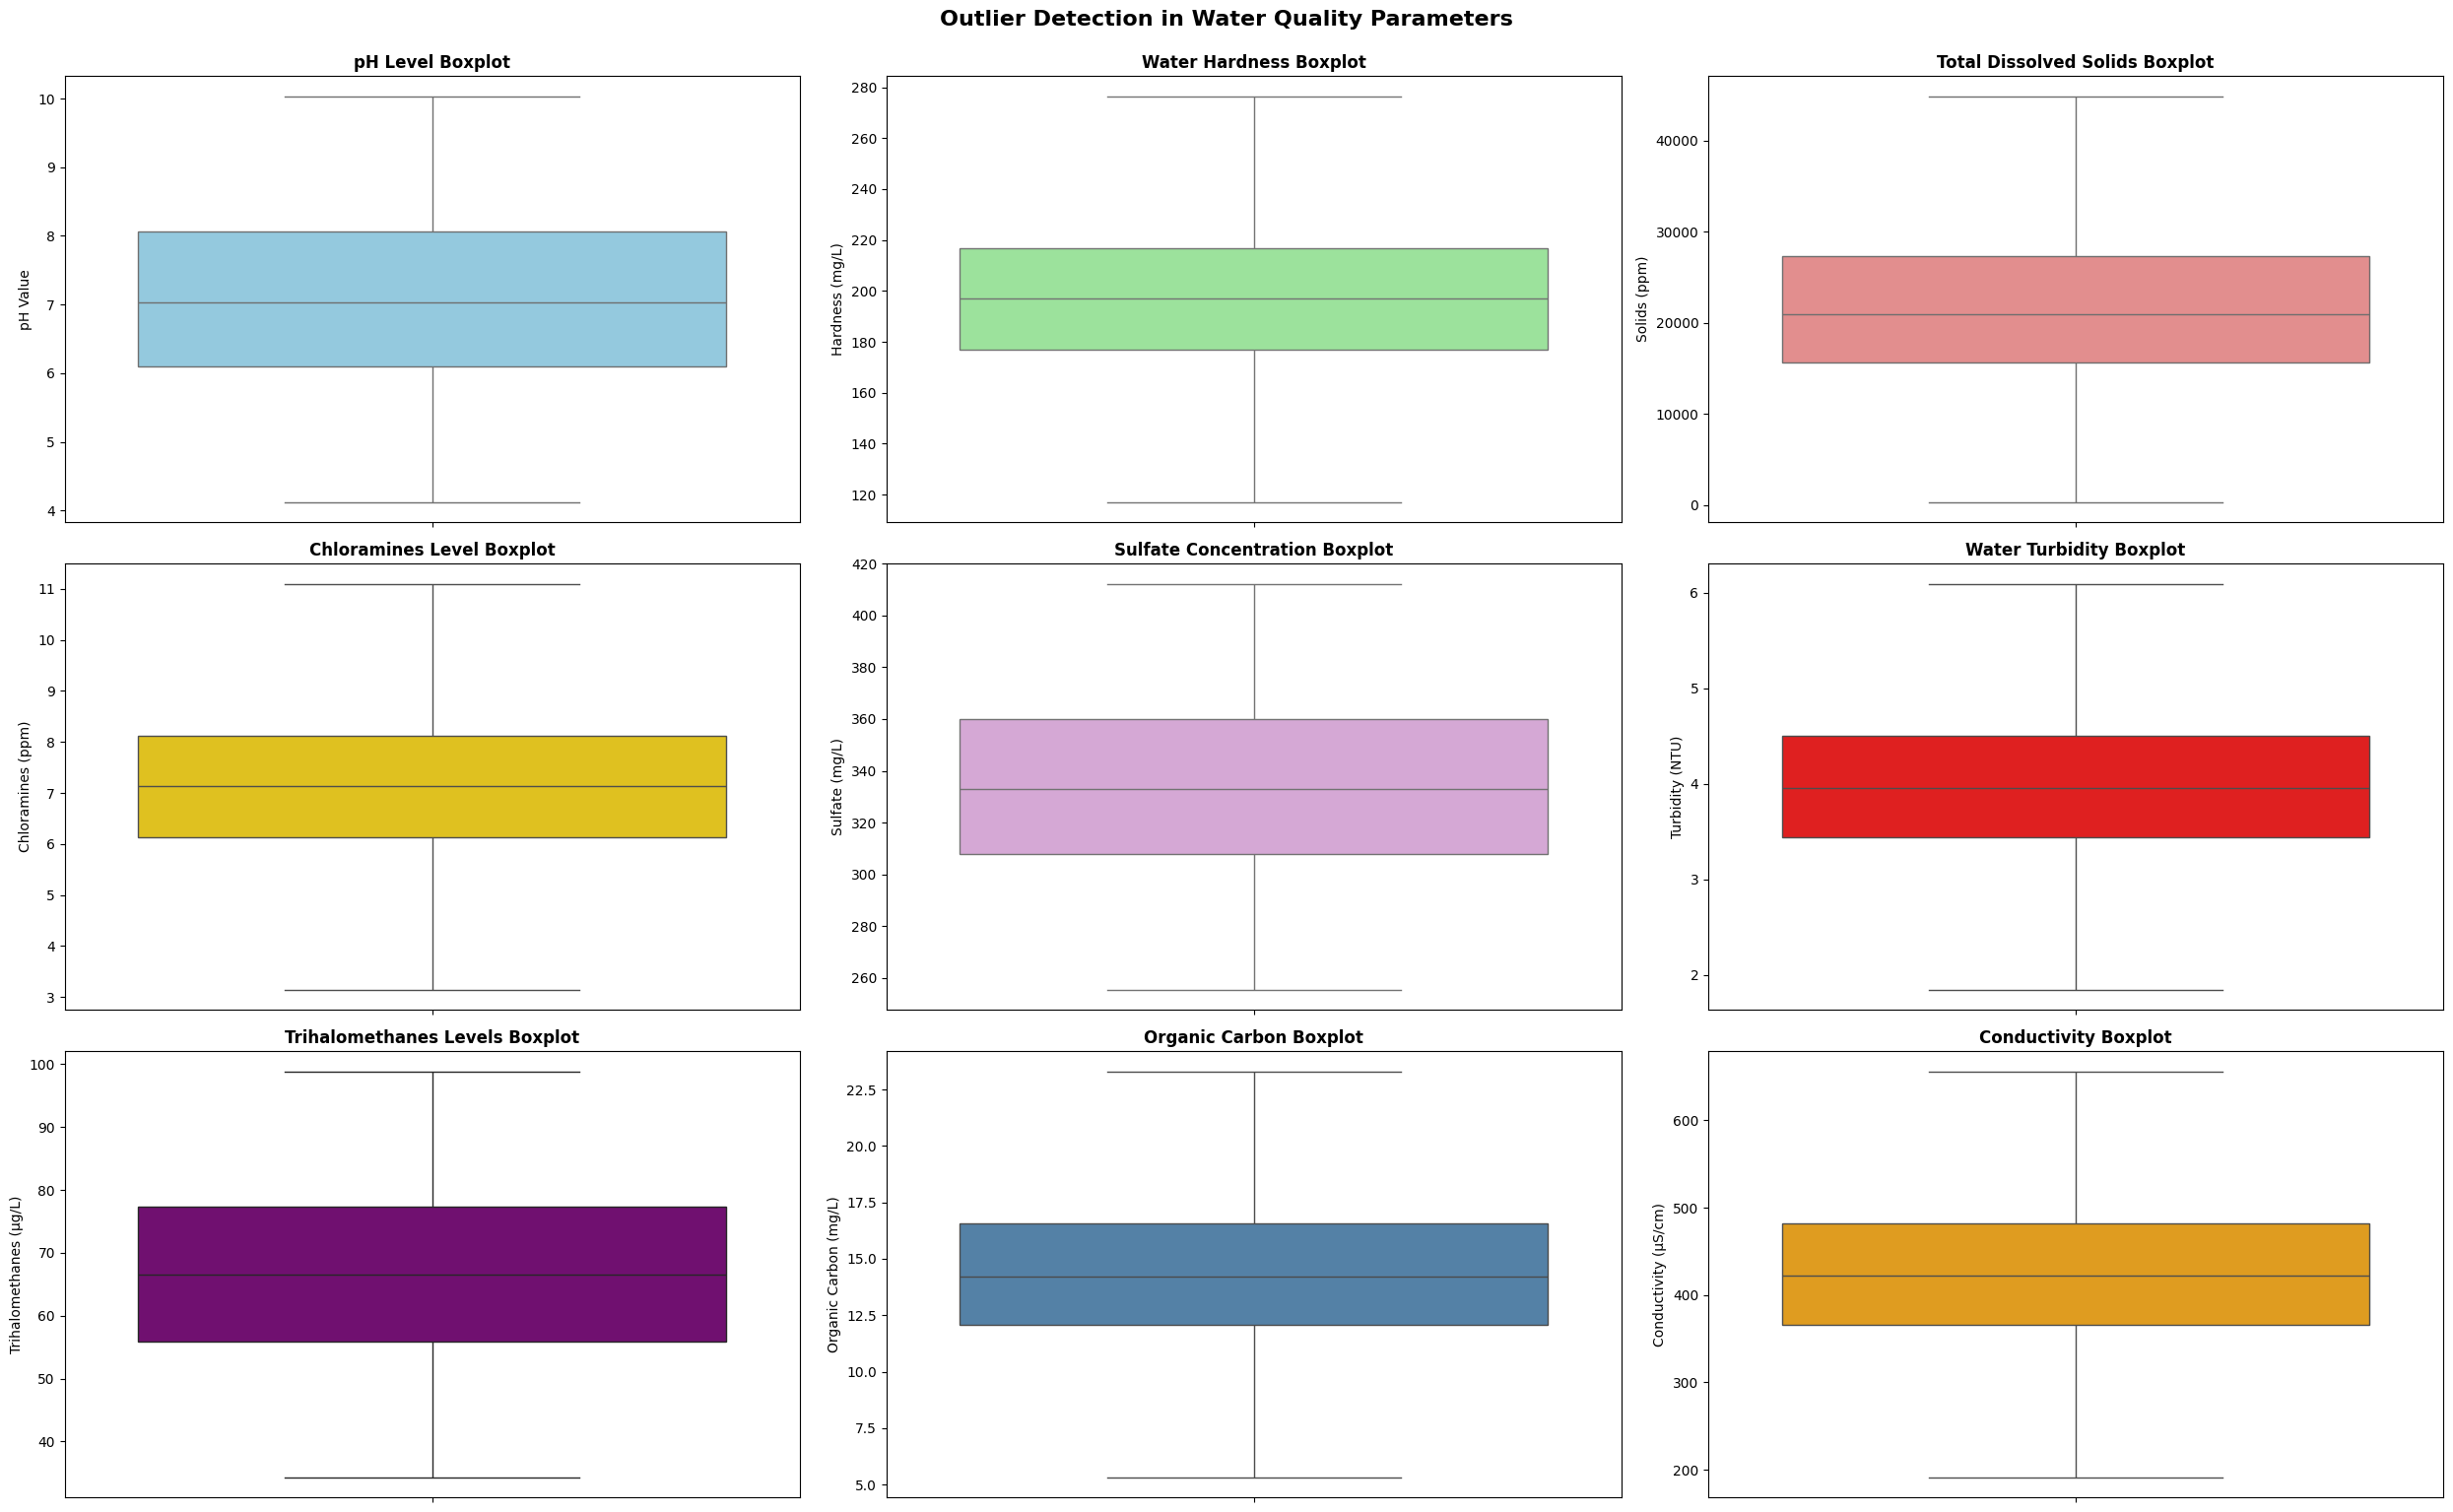

In [101]:
plt.figure(figsize=(25, 15))


plt.subplot(3, 3, 1)
box1 = sns.boxplot(y=water_potability_clean['ph'].dropna(), color='skyblue')
plt.title('pH Level Boxplot', fontweight='bold')
plt.ylabel('pH Value')

plt.subplot(3, 3, 2)
box2 = sns.boxplot(y=water_potability_clean['Hardness'].dropna(), color='lightgreen')
plt.title('Water Hardness Boxplot', fontweight='bold')
plt.ylabel('Hardness (mg/L)')

plt.subplot(3, 3, 3)
box3 = sns.boxplot(y=water_potability_clean['Solids'].dropna(), color='lightcoral')
plt.title('Total Dissolved Solids Boxplot', fontweight='bold')
plt.ylabel('Solids (ppm)')

plt.subplot(3, 3, 4)
box4 = sns.boxplot(y=water_potability_clean['Chloramines'].dropna(), color='gold')
plt.title('Chloramines Level Boxplot', fontweight='bold')
plt.ylabel('Chloramines (ppm)')

plt.subplot(3, 3, 5)
box5 = sns.boxplot(y=water_potability_clean['Sulfate'].dropna(), color='plum')
plt.title('Sulfate Concentration Boxplot', fontweight='bold')
plt.ylabel('Sulfate (mg/L)')

plt.subplot(3, 3, 6)
sns.boxplot(y=water_potability_clean['Turbidity'].dropna(), color='red')
plt.title('Water Turbidity Boxplot', fontweight='bold')
plt.ylabel('Turbidity (NTU)')

plt.subplot(3, 3, 7)
box7 = sns.boxplot(y=water_potability_clean['Trihalomethanes'].dropna(), color='purple')
plt.title('Trihalomethanes Levels Boxplot', fontweight='bold')
plt.ylabel('Trihalomethanes (µg/L)')

plt.subplot(3, 3, 8)
box8 = sns.boxplot(y=water_potability_clean['Organic_carbon'].dropna(), color='steelblue')
plt.title('Organic Carbon Boxplot', fontweight='bold')
plt.ylabel('Organic Carbon (mg/L)')

plt.subplot(3, 3, 9)
box9 = sns.boxplot(y=water_potability_clean['Conductivity'].dropna(), color='orange')
plt.title('Conductivity Boxplot', fontweight='bold')
plt.ylabel('Conductivity (µS/cm)')

plt.tight_layout()
plt.suptitle('Outlier Detection in Water Quality Parameters', fontsize=16, fontweight='bold', y=1.02)
plt.show()

#### 6. Data Cleaning

In [102]:
# Check missing values BEFORE imputation
print("\nMissing values BEFORE imputation:")
print(water_potability_clean.isnull().sum())


Missing values BEFORE imputation:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [103]:
# Define imputer with median strategy
imputer = SimpleImputer(strategy='median')

# Apply imputer to columns with missing values
water_potability_clean[['ph', 'Sulfate', 'Trihalomethanes']] = imputer.fit_transform(
    water_potability_clean[['ph', 'Sulfate', 'Trihalomethanes']]
)

print("Missing values after imputation:\n", water_potability_clean.isnull().sum())

Missing values after imputation:
 ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


#### Feature Selection and Engineering

 New features are created from existing water quality parameters based on WHO and EPA recommended safety thresholds. Each feature converts a raw numerical value into a simple binary flag (1 = safe, 0 = unsafe) to give the model a more direct and meaningful signal for predicting potability

In [104]:
# FEATURE 1: pH Safety Flag (ph_safe)

water_potability_clean['ph_safe'] = ((water_potability_clean['ph'] >= 6.5) & (water_potability_clean['ph'] <= 8.5)).astype(int)

# pH measures how acidic or alkaline the water is (scale 0-14)
# WHO recommends a safe drinking water pH range of 6.5 to 8.5
# Water outside this range can cause digestive issues and pipe corrosion at low pH, or skin irritation at high pH.
# This feature assigns:
#   1 = pH is within the safe range (6.5 - 8.5)
#   0 = pH is outside the safe range (too acidic or too alkaline)

In [105]:
# FEATURE 2: Chloramine Safety Flag (chloramine_safe)

water_potability_clean['chloramine_safe'] = (water_potability_clean['Chloramines'] <= 4).astype(int)

# Chloramines are disinfectants added to water during treatment to kill harmful bacteria and viruses.
# The EPA sets the safe limit for Chloramines at 4 ppm.
# Levels above 4 ppm can cause respiratory issues and kidney problems with prolonged exposure.
# This feature assigns:
#   1 = Chloramine level is within the safe limit (≤ 4 ppm)
#   0 = Chloramine level exceeds the safe limit (> 4 ppm)

In [106]:
# FEATURE 3: Turbidity Safety Flag (turbidity_safe)

water_potability_clean['turbidity_safe'] = (water_potability_clean['Turbidity'] <= 5).astype(int)

# Turbidity measures how clear or cloudy the water is. It is caused by suspended particles such as dirt, bacteria, algae and waste matter. It is measured in NTU.
# High turbidity can hide harmful bacteria and viruses, making water disinfection less effective.
# This feature assigns:
#   1 = Turbidity is within the acceptable range (≤ 5 NTU)
#   0 = Turbidity exceeds the acceptable range (> 5 NTU)

In [107]:

print("Feature engineering complete!")
print(water_potability_clean[['ph_safe', 'chloramine_safe', 'turbidity_safe']])

Feature engineering complete!
      ph_safe  chloramine_safe  turbidity_safe
0           1                0               1
1           0                0               1
2           1                0               1
3           1                0               1
4           0                0               1
...       ...              ...             ...
3271        0                0               1
3272        1                0               1
3273        0                0               1
3274        0                0               1
3275        1                0               1

[3276 rows x 3 columns]


### Scaling or Normalization

Scaling or normalization is the process of standardizing the range of features or variables in the dataset.

In [108]:
selected_features =['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

x= water_potability_clean[selected_features] # Independent Variables
y= water_potability_clean['Potability'] # Dependent variable (the target variable)

In [109]:
# Scaling
scaler = MinMaxScaler() # (Scales to range [0, 1])
x[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']] = scaler.fit_transform(x[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']])


### Train-Test Split

The dataset is split into training and testing sets. 80% of the data is used for training the model and 20% is used for testing and evaluating model performance.

In [110]:
# Separate features and target

x = water_potability_clean[selected_features]
y = water_potability_clean['Potability']

# Split (80% train, 20% test)
train_x, test_x, train_y, test_y = train_test_split(
    x, y, random_state=42, train_size=0.8)

In [111]:
print(f"\n✅ Train-test split complete:")
print(f"   x_train: ({train_x.shape}")
print(f"   x_test: {test_x.shape}")
print(f"   y_train: {train_y.shape}")
print(f"   y_test: {test_y.shape}")


✅ Train-test split complete:
   x_train: ((2620, 9)
   x_test: (656, 9)
   y_train: (2620,)
   y_test: (656,)


#### Training the Models

#### 1. Using K-Nearest Neighbours (KNN)

KNN classifies a water sample by looking at the K closest samples in the training data and assigning the majority class.

n_neighbors=5 means the model looks at the 5 closest data points to make a prediction.

In [124]:
# Train model
kneighbor = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform', algorithm='auto', leaf_size=50, p=2)
kneighbor.fit(train_x, train_y)


KNeighborsClassifier(leaf_size=50, metric='euclidean')

In [125]:
# Making predictions

val_prediction = kneighbor.predict(test_x) # This uses the trained KNN model to predict the potability (0 or 1) for each water sample in the test set (test_x).
y_pred_proba = kneighbor.predict_proba(test_x)[:,1] # This predicts the probability of each sample being potable.
print("Predictions complete!")

Predictions complete!


In [126]:
# Evaluate model performance
accuracy = accuracy_score(test_y, val_prediction)
print(f'Model accuracy: {accuracy}')
# This compares the actual potability values from the test set (test_y) against what the model predicted (val_prediction) and calculates the percentage of correct predictions.
# The result is stored in accuracy as a number between 0 and 1.

Model accuracy: 0.5350609756097561


In [127]:
# Generate confusion matrix and classification report
print(confusion_matrix(test_y, val_prediction))
print(classification_report(test_y, val_prediction))

[[291 121]
 [184  60]]
              precision    recall  f1-score   support

           0       0.61      0.71      0.66       412
           1       0.33      0.25      0.28       244

    accuracy                           0.54       656
   macro avg       0.47      0.48      0.47       656
weighted avg       0.51      0.54      0.52       656



In [128]:
# AUC score measures how well the model separates potable from non-potable water
# A score of 0.5 = random guessing, 1.0 = perfect model

auc = roc_auc_score(test_y, y_pred_proba)
print(auc)

# Our score of 0.48 indicates the model is performing below random guessing

0.48224375298424327


In [129]:
# Save model
joblib.dump(kneighbor, 'water_potability_model.pkl')

['water_potability_model.pkl']

#### Using Decision Tree Model

Decision Tree classifies a water sample by asking a series of yes/no questions
about the water quality parameters. It creates a tree-like structure where:
- Each node asks a question (e.g., "Is pH > 7.0?")
- Each branch is an answer (Yes/No)
- Each leaf gives the final prediction (Potable/Non-Potable)

In [157]:
# Train model

# max_depth: How deep the tree can grow (prevents overfitting)
# random_state: Ensures reproducible results
# criterion: How to measure split quality ('gini' or 'entropy')

decision_tree = DecisionTreeClassifier(
    max_depth=5,           # Limits tree depth to prevent overfitting
    random_state=42,       # Reproducible results
    criterion='gini'       # Measure of impurity (gini or entropy)
)
decision_tree.fit(train_x, train_y)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [158]:
# Making predictions

# predict() returns the class predictions (0 or 1)
# predict_proba() returns probability of each class (useful for ROC-AUC)

val_prediction = decision_tree.predict(test_x)           #  This uses the trained Random Forest model to predict the potability (0 or 1) for each water sample in the test set (test_x).
y_pred_proba = decision_tree.predict_proba(test_x)[:,1]  # This predicts the probability of each sample being potable.
print("Predictions complete!")

Predictions complete!


In [159]:
# Evaluate model performance
accuracy = accuracy_score(test_y, val_prediction)
print(f'Model accuracy: {accuracy}')
# This compares the actual potability values from the test set (test_y) against what the model predicted (val_prediction) and calculates the percentage of correct predictions.
# The result is stored in accuracy as a number between 0 and 1.


Model accuracy: 0.6371951219512195


In [160]:
# Generate confusion matrix and classification report

# Confusion matrix shows:
# - Top-left: True Negatives (correctly predicted Non-Potable)
# - Top-right: False Positives (wrongly predicted Potable)
# - Bottom-left: False Negatives (wrongly predicted Non-Potable)
# - Bottom-right: True Positives (correctly predicted Potable)

print("\nConfusion Matrix:")
print(confusion_matrix(test_y, val_prediction))

print("\nClassification Report:")
print(classification_report(test_y, val_prediction))


Confusion Matrix:
[[362  50]
 [188  56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.88      0.75       412
           1       0.53      0.23      0.32       244

    accuracy                           0.64       656
   macro avg       0.59      0.55      0.54       656
weighted avg       0.61      0.64      0.59       656



In [161]:
# AUC Score (Area Under ROC Curve)

# AUC measures how well the model separates potable from non-potable water.
# 0.5 = random guessing (no predictive power)
# 0.7 = acceptable model
# 0.8 = good model
# 0.9 = excellent model
# 1.0 = perfect model

auc = roc_auc_score(test_y, y_pred_proba)
print(auc)

0.6054283383733885


In [162]:
# Save model
joblib.dump(decision_tree, 'water_potability_tree model.pkl')

['water_potability_tree model.pkl']

#### Using the Random Forest Model

Random Forest is an ensemble of many decision trees. It combines multiple trees to make more accurate predictions and reduce overfitting.

n_estimators=100 means the forest has 100 trees.


In [145]:
# Train model

# n_estimators: Number of trees in the forest (more trees = better, but slower)
# random_state: Ensures reproducible results
# n_jobs=-1: Uses all CPU cores for faster training

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(train_x, train_y)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [146]:
# Making predictions

# predict() returns the class predictions (0 or 1)
# predict_proba() returns probability of each class (useful for ROC-AUC)

val_prediction = rf_model.predict(test_x)           #  This uses the trained Random Forest model to predict the potability (0 or 1) for each water sample in the test set (test_x).
y_pred_proba = rf_model.predict_proba(test_x)[:,1]  # This predicts the probability of each sample being potable.
print("Predictions complete!")

Predictions complete!


In [147]:
# Evaluate model performance
accuracy = accuracy_score(test_y, val_prediction)
print(f'Model accuracy: {accuracy}')
# This compares the actual potability values from the test set (test_y) against what the model predicted (val_prediction) and calculates the percentage of correct predictions.
# The result is stored in accuracy as a number between 0 and 1.


Model accuracy: 0.6935975609756098


In [148]:
# Generate confusion matrix and classification report

# Confusion matrix shows:
# - Top-left: True Negatives (correctly predicted Non-Potable)
# - Top-right: False Positives (wrongly predicted Potable)
# - Bottom-left: False Negatives (wrongly predicted Non-Potable)
# - Bottom-right: True Positives (correctly predicted Potable)

print("\nConfusion Matrix:")
print(confusion_matrix(test_y, val_prediction))

print("\nClassification Report:")
print(classification_report(test_y, val_prediction))


Confusion Matrix:
[[366  46]
 [155  89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.89      0.78       412
           1       0.66      0.36      0.47       244

    accuracy                           0.69       656
   macro avg       0.68      0.63      0.63       656
weighted avg       0.69      0.69      0.67       656



In [151]:
# AUC Score (Area Under ROC Curve)

# AUC measures how well the model separates potable from non-potable water.
# 0.5 = random guessing (no predictive power)
# 0.7 = acceptable model
# 0.8 = good model
# 0.9 = excellent model
# 1.0 = perfect model

auc = roc_auc_score(test_y, y_pred_proba)
print(auc)

0.6860675632659557


In [163]:
# Save model
joblib.dump(rf_model, 'water_potability_rf model.pkl')

['water_potability_rf model.pkl']